In [2]:
#utils I made to look at this data
import switchy.util as ut
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl

import seaborn as sns
import autoreload
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../data/"
#import auto reload
%load_ext autoreload
%autoreload 2

In [3]:
sc.set_figure_params(color_map='viridis')

# Load Data and filter

In [4]:
adata = sc.read_h5ad('/home/mswift/B_cells/CSR/switchy/data/CombinedDivisionImmcantation.h5ad')

In [5]:
adata = ut.preprocessScanpy(adata, num_counted_reads=80000, num_genes=500, min_cells=40, n_neighbors=15, num_highly_variable=2000)

making var_names unique
filtering cells with less than 80000 counted reads
filtering cells with less than 500 genes detected
filtering genes detected in less than 40
normalizing by total counts per cell
log transforming data
removed ERCC sequences from genes to cluster on
removing variable immune receptor genes which may drive clustering
calculating highly variable genes


Trying to set attribute `.var` of view, copying.


calculating PCA
creating neighbors graph with 15


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:121: FutureWarning: This location for 'distances' is deprecated. It has been moved to .obsp[distances], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['distances'] = neighbors.distances
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:122: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'] = neighbors.connectivities
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/tools/_umap.py:147: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'].tocoo()

umapping and tsne-ing


In [6]:
sc.tl.leiden(adata, resolution = 0.3)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/tools/_leiden.py:111: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adjacency = adata.uns['neighbors']['connectivities']


# Correlation Analysis

In [10]:
# Try to remove the ERCCs
_adata = sc.read_h5ad('../../data/CombinedDivisionImmcantation.h5ad')

_adata.obs.index = _adata.obs.index.str[:-2]

ERCCs = _adata.var.index[_adata.var.index.str.contains("ERCC-|NIST")].to_list()

_adata = _adata[:, ~_adata.var.index.isin(ERCCs)]

In [11]:
sc.pp.filter_cells(_adata, min_counts=80000, inplace=True)
sc.pp.filter_genes(_adata, min_cells=120, inplace=True)

Trying to set attribute `.obs` of view, copying.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [12]:
sc.pp.normalize_total(_adata, exclude_highly_expressed=False, inplace=True, target_sum=1e6)

In [13]:
# Get raw df with cells and genes 

df = pd.DataFrame(_adata.X)
df.set_index(_adata.obs.index, inplace = True)
df.columns = _adata.var.index
# Log 10 transform it 
df_log = np.log10(df + 1)

In [14]:
# Use Numpy to do the Pearson Correllation of all values
# Did this because pandas corr is very slow, must be a bug.. 
df_corr = np.corrcoef(df_log.values, rowvar=False) 

# Put the labels back on and make it a df
df_corr = pd.DataFrame(df_corr, index = df_log.columns, columns=df_log.columns)

# Check that the matrix looks correct
df_corr.head()

,WASH7P,FO538757.1,MTND1P23,MTND2P28,ENSG00000276171,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,MTCO3P12,AL669831.5,LINC01128,NOC2L,ISG15,AL390719.1,C1orf159,SDF4,B3GALT6,UBE2J2,ACAP3,PUSL1,INTS11,CPTP,DVL1,AURKAIP1,CCNL2,AL391244.1,MRPL20,ATAD3B,ATAD3A,SSU72,AL691432.2,MIB2,CDK11B,SLC35E2B,CDK11A,AL031282.2,SLC35E2,NADK,GNB1,FAAP20,MORN1,RER1,PEX10,PANK4,TNFRSF14-AS1,TNFRSF14,FAM213B,TPRG1L,WRAP73,TP73-AS1,LRRC47,CEP104,DFFB,C1orf174,KCNAB2,RPL22,RNF207,ICMT,ACOT7,NOL9,AL591866.1,ZBTB48,KLHL21,PHF13,THAP3,DNAJC11,CAMTA1,VAMP3,TNFRSF9,PARK7,RERE,ENO1,ENSG00000236269,HMGN2P17,SLC2A5,H6PD,SLC25A33,AL954705.1,TMEM201,PIK3CD,PIK3CD-AS1,PIK3CD-AS2,CLSTN1,CTNNBIP1,LZIC,AL357140.2,NMNAT1,UBE4B,KIF1B,PGD,CENPS,DFFA,PEX14,CASZ1,TARDBP,SRM,EXOSC10,MTOR,UBIAD1,FBXO44,FBXO6,MAD2L2,AGTRAP,MTHFR,CLCN6,KIAA2013,PLOD1,MFN2,MIIP,TNFRSF8,TNFRSF1B,VPS13D,HNRNPCL1,PRDM2,EFHD2,CASP9,DNAJC16,CHCHD2P6,DDI2,PLEKHM2,RPL12P14,UQCRHL,AL450998.1,AL450998.2,SPEN,ZBTB17,FBXO42,SZRD1,NECAP2,NBPF1,ENSG00000282056,CROCCP2,EIF1AXP1,CROCC,ATP13A2,SDHB,RCC2,ALDH4A1,IFFO2,UBR4,EMC1,MRTO4,AKR7A2,PQLC2,CAPZB,MINOS1,AL031727.1,TMCO4,OTUD3,MUL1,DDOST,HP1BP3,EIF4G3,ECE1,NBPF3,ALPL,USP48,AL590556.1,LINC00339,CDC42,ZBTB40,KDM1A,LUZP1,LINC01355,HNRNPR,E2F2,ID3,RPL11,ELOA,ELOA-AS1,PITHD1,LYPLA2,GALE,HMGCL,FUCA1,CNR2,AL590609.2,PNRC2,SRSF10,IFNLR1,STPG1,NIPAL3,RCAN3,SRRM1,CLIC4,RUNX3,SYF2,RSRP1,SDHDP6,TMEM50A,AL031284.1,MACO1,SELENON,MTFR1L,AUNIP,PAQR7,STMN1,PAFAH2,PDIK1L,AL355877.3,CEP85,SH3BGRL3,UBXN11,CD52,DHDDS,AL513365.1,HMGN2,RPS6KA1,ARID1A,PIGV,ZDHHC18,GPN2,GPATCH3,NUDC,RPL12P13,OSTCP2,SLC9A1,CHCHD3P3,NPM1P39,WDTC1,FO393419.3,TMEM222,ACTG1P20,SYTL1,MAP3K6,WASF2,AL031729.1,IFI6,FAM76A,STX12,PPP1R8,THEMIS2,RPA2,XKR8,EYA3,SPCS2P4,PTAFR,DNAJC8,ATP5IF1,AL353622.1,SESN2,MED18,PHACTR4,CR391992.1,RCC1,SNHG3,SNORA73B,TRNAU1AP,SNHG12,...,UQCRFS1P1,Z82206.1,TNRC6B,ADSL,SGSM3,MKL1,SLC25A17,ST13,XPNPEP3,RBX1,AL080243.2,AL080243.1,EP300,L3MBTL2,RANGAP1,ZC3H7B,TOB2,PHF5A,ACO2,POLR3H,PMM1,DESI1,XRCC6,SNU13,C22orf46,MEI1,AL021453.1,SREBF2,TNFRSF13C,CENPM,NAGA,SNORD13P1,SMDT1,NDUFA6,OLA1P1,TCF20,RRP7A,SERHL2,RRP7BP,POLDIP3,CYB5R3,ATP5MGL,RPL5P34,ARFGAP3,PACSIN2,TTLL1,MCAT,TSPO,TTLL12,SAMM50,AL035398.1,PARVB,AL031595.3,PARVG,RTL6,NUP50-AS1,NUP50,KIAA0930,FAM118A,SMC1B,Z95331.1,ATXN10,PRR34-AS1,PPARA,CDPF1,TTC38,GTSE1,TRMU,CERK,AL118516.1,TBC1D22A,C22orf34,Z97192.3,BRD1,ZBED4,ALG12,CRELD2,PIM3,TRABD,SELENOO,TUBGCP6,MAPK12,PLXNB2,DENND6B,PPP6R2,SBF1,ADM2,LMF2,NCAPH2,SCO2,TYMP,ODF3B,ARSA,AC002056.1,RPL23AP82,RABL2B,FP565260.6,FP565260.1,FP565260.7,CBSL,U2AF1L5,FP671120.3,FP671120.4,FP236383.2,FP236383.3,CR381670.1,TEKT4P2,CR381653.1,EIF3FP1,ANKRD20A11P,AP001347.1,HSPA13,SAMSN1,NRIP1,USP25,BTG3,C21orf91,PPIAP22,EEF1A1P1,LINC01684,RPL13AP7,LINC00158,MIR155HG,MRPL39,JAM2,ATP5PF,GABPA,APP,GPX1P2,RPL10P1,N6AMT1,LTN1,RWDD2B,USP16,CCT8,BACH1,TIAM1,SOD1,SCAF4,MIS18A,URB1,URB1-AS1,EXOSC3P1,C21orf59,SYNJ1,PAXBP1,IFNAR2,IL10RB-AS1,IL10RB,IFNAR1,IFNGR2,TMEM50B,GART,SON,DONSON,CRYZL1,ITSN1,ATP5PO,LINC00649,MRPS6,SLC5A3,RPS5P2,SMIM11A,RCAN1,CLIC6,RUNX1,SETD4,CBR1,MEMO1P1,CBR3-AS1,DOPEY2,RPL3P1,MORC3,CHAF1B,CLDN14,AP000695.3,HLCS,PIGP,TTC3,VPS26C,DYRK1A,RPL23AP12,PSMG1,BRWD1,HMGN1,WRB,MX2,MX1,PRDM15,C2CD2,ZBTB21,ZNF295-AS1,SLC37A1,WDR4,NDUFV3,PKNOX1,U2AF1,RPL31P1,RRP1B,PDXK,CSTB,RRP1,AGPAT3,TRAPPC10,H2AFZP1,PWP2,C21orf33,PFKL,C21orf2,UBE2G2,SUMO3,PTTG1IP,ITGB2,ITGB2-AS1,LINC01547,FAM207A,ADARB1,SLC19A1,SPATC1L,LSS,MCM3AP-AS1,MCM3AP,YBEY,C21orf58,PCNT,DIP2A,PRMT2,MT-RNR1,MT-RNR2,MT-TL1,MT-ND1,MT-ND2,MT-TC,MT-TY,MT-CO1,MT-CO2,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,MT-TP,ENSG00000277048,AL592183.1,AC004556.1,AC240274.1
WASH7P,1.000000,0.346148,0.043436,-0.014067,-0.025600,0.018644,-0.055726,-0.034236,-0.011334,-0.055405,0.018760,0.070350,0.006156,-0.023622,0.019293,0.020085,0.027904,0.024216,0.051453,0.024480,0.053455,0.002306,0.050317,0.023779,0.042211,0.018323,0.021365,-0.005776,0.020341,0.030178,0.010493,-0.014594,0.028921,0.049626,-0.013415,0.010861,0.026743,0.014576,0.055244,-0.00

In [16]:
# Bootstrap 
# Make a deep copy of the df_log so that I can shuffle AICDA Column
LiOfSerAICDA = [] 
_df = df_log.copy(deep = True)
for i in range(1000): 
    np.random.shuffle(_df['AICDA'])
    _df_corr = np.corrcoef(_df.values, rowvar=False)
    _df_corr = pd.DataFrame(_df_corr, index = _df.columns, columns=_df.columns)
    LiOfSerAICDA.append(_df_corr['AICDA'])
    
df = pd.DataFrame(LiOfSerAICDA)
df.reset_index(inplace = True)
df.to_feather('test_df.fthr')    

(array([1.000e+01, 2.100e+01, 3.900e+01, 8.800e+01, 2.090e+02, 6.140e+02,
        1.239e+03, 1.957e+03, 2.031e+03, 1.605e+03, 1.161e+03, 8.770e+02,
        5.970e+02, 4.410e+02, 3.240e+02, 2.480e+02, 2.030e+02, 1.610e+02,
        9.600e+01, 8.500e+01, 3.400e+01, 2.200e+01, 9.000e+00, 1.000e+01,
        8.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00]),
 array([-0.2       , -0.17435897, -0.14871795, -0.12307692, -0.0974359 ,
        -0.07179487, -0.04615385, -0.02051282,  0.00512821,  0.03076923,
         0.05641026,  0.08205128,  0.10769231,  0.13333333,  0.15897436,
         0.18461538,  0.21025641,  0.23589744,  0.26153846,  0.28717949,
         0.31282051,  0.33846154,  0.36410256,  0.38974359,  0.41538462,
         0.44102564,  0.46666667,  0.49230769,  0.51794872,  0.54358974,
         0.56923077,  0.59487179,  0.62051282,  0.64615385,  0.67179487,
  

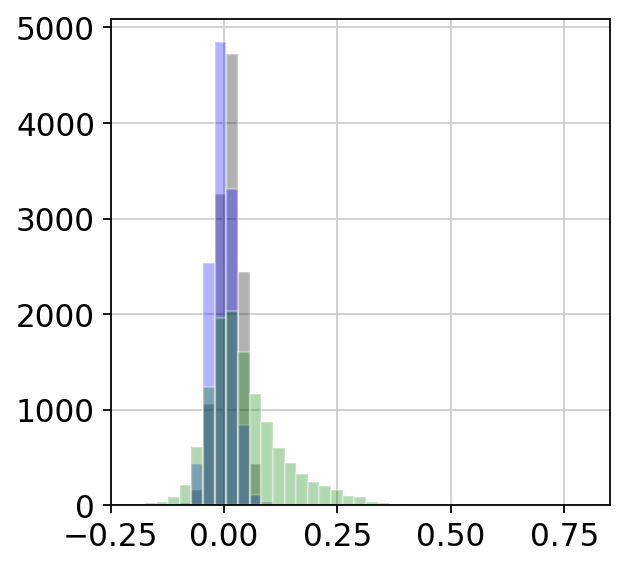

In [17]:
fig, ax = plt.subplots(1,1)
bins = np.linspace(-0.2, 0.8, 40)
plt.hist(LiOfSerAICDA[0], bins = bins, alpha = 0.3, color = 'k')
plt.hist(LiOfSerAICDA[1], bins = bins, alpha = 0.3, color = 'b')
plt.hist(df_corr['AICDA'], bins = bins, alpha = 0.3, color = 'g')

In [22]:
# B cell genes of interest! 
BCGs = ['AICDA', 'PRDM1', 'BACH2', 'ARID5A', 'CR2', 'IL10']

### Plot the Distributions of Peason Correlation Coeffs

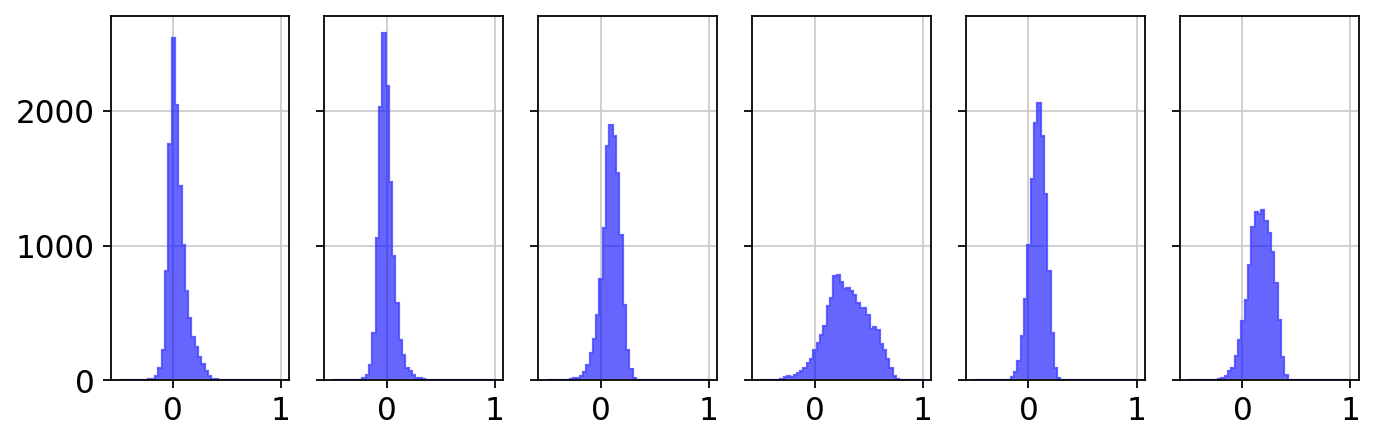

In [23]:
fig, ax = plt.subplots(1, len(BCGs), sharey = True, figsize = (10,3))

DictofSerGenes = {}
bins = np.linspace(-0.5, 1, 50)
for i, GOI in enumerate(BCGs):
    
    ax[i].hist(df_corr[GOI], histtype='stepfilled', alpha = 0.6,color = 'b' ,bins = bins)
    ax[i].hist(df_corr[GOI], histtype='step', alpha = 0.6, color = 'b', bins = bins)
    #Create a dictionary where the key is the gene of interest and the most correlated genes are the values 
    DictofSerGenes.update({GOI:df_corr[GOI].sort_values(ascending = False)[:500]})

In [24]:
# Just plot the GOI (Gene of Interest)

In [25]:
GOI = 'AICDA'
#GOI = 'ARID5A'


Text(0.5, 0, 'Pearson with AID')

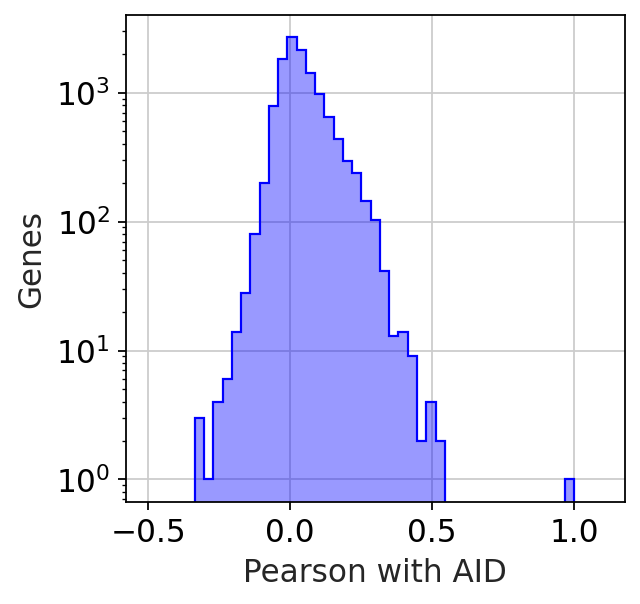

In [26]:
fig, ax = plt.subplots(1,1)

bins = np.linspace(-0.5, 1.1, 50)

plt.hist(df_corr[GOI], histtype='stepfilled', alpha = 0.4,color = 'b' ,bins = bins)
plt.hist(df_corr[GOI], histtype='step', alpha = 1, color = 'b', bins = bins)

plt.yscale('log')
plt.ylabel('Genes')
plt.xlabel('Pearson with AID')


In [27]:
# For GOI take the top 500 Pearson Correlated Genes
TopPearson = DictofSerGenes[GOI][:1000].index.to_list()

In [28]:
# Transform the Raw Data TODO: Refactor to make this happen only once and early
gene_df = df_log

In [29]:
# Subset the Df by these genes in order to make the spearman calculation manageable
small_df = gene_df[TopPearson]

In [30]:
# Spearman Corr of the genes with each other amongts all the cells 
df_spear =  small_df.corr(method='spearman')

In [31]:
df_spear['AICDA'].sort_values(ascending= False)

AICDA              1.000000
MIR4435-2HG        0.509176
MSC                0.500951
AC017002.3         0.478564
GCSAM              0.472934
IGHG2              0.460545
HSPB1              0.456429
TOX2               0.450423
AC012236.1         0.449662
IGHG1              0.442937
HLA-DQB1           0.442549
HSPB1P2            0.441485
LINC01943          0.438653
SEC11C             0.430789
HLA-DQA1           0.424023
TOX                0.423173
GSTP1              0.419145
SHOX2              0.418736
CLECL1             0.409641
POU2AF1            0.408794
TNFRSF17           0.406932
KCNMA1             0.402366
IGHG4              0.400151
IGHG3              0.398772
JCHAIN             0.398730
BEX3               0.394825
MIR8071-2          0.394717
TBCA               0.393288
AL928742.1         0.393162
CADM1              0.389316
ENSG00000275301    0.388070
HSPB1P1            0.387341
GLRX               0.382950
TVP23A             0.381926
TCTN1              0.380744
IGKV3OR2-268       0

Text(0.5, 0, 'Spearman with AID')

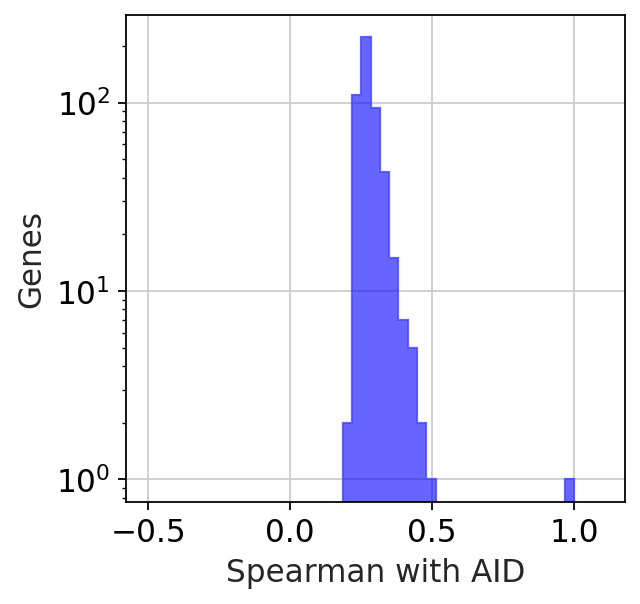

In [47]:
_df = df_spear

fig, ax = plt.subplots(1,1)

bins = np.linspace(-0.5, 1.1, 50)

plt.hist(_df[GOI], histtype='stepfilled', alpha = 0.6,color = 'b' ,bins = bins)
plt.hist(_df[GOI], histtype='step', alpha = 0.6, color = 'b', bins = bins)

plt.yscale('log')
plt.ylabel('Genes')
plt.xlabel('Spearman with AID')

In [48]:
TopCorrelatedGOI_GOIS = _df[GOI].index[:10]

In [49]:
TopCorrelatedGOI_GOI = _df[GOI].index[0]

In [50]:
genes2plot = TopCorrelatedGOI_GOIS.to_list()

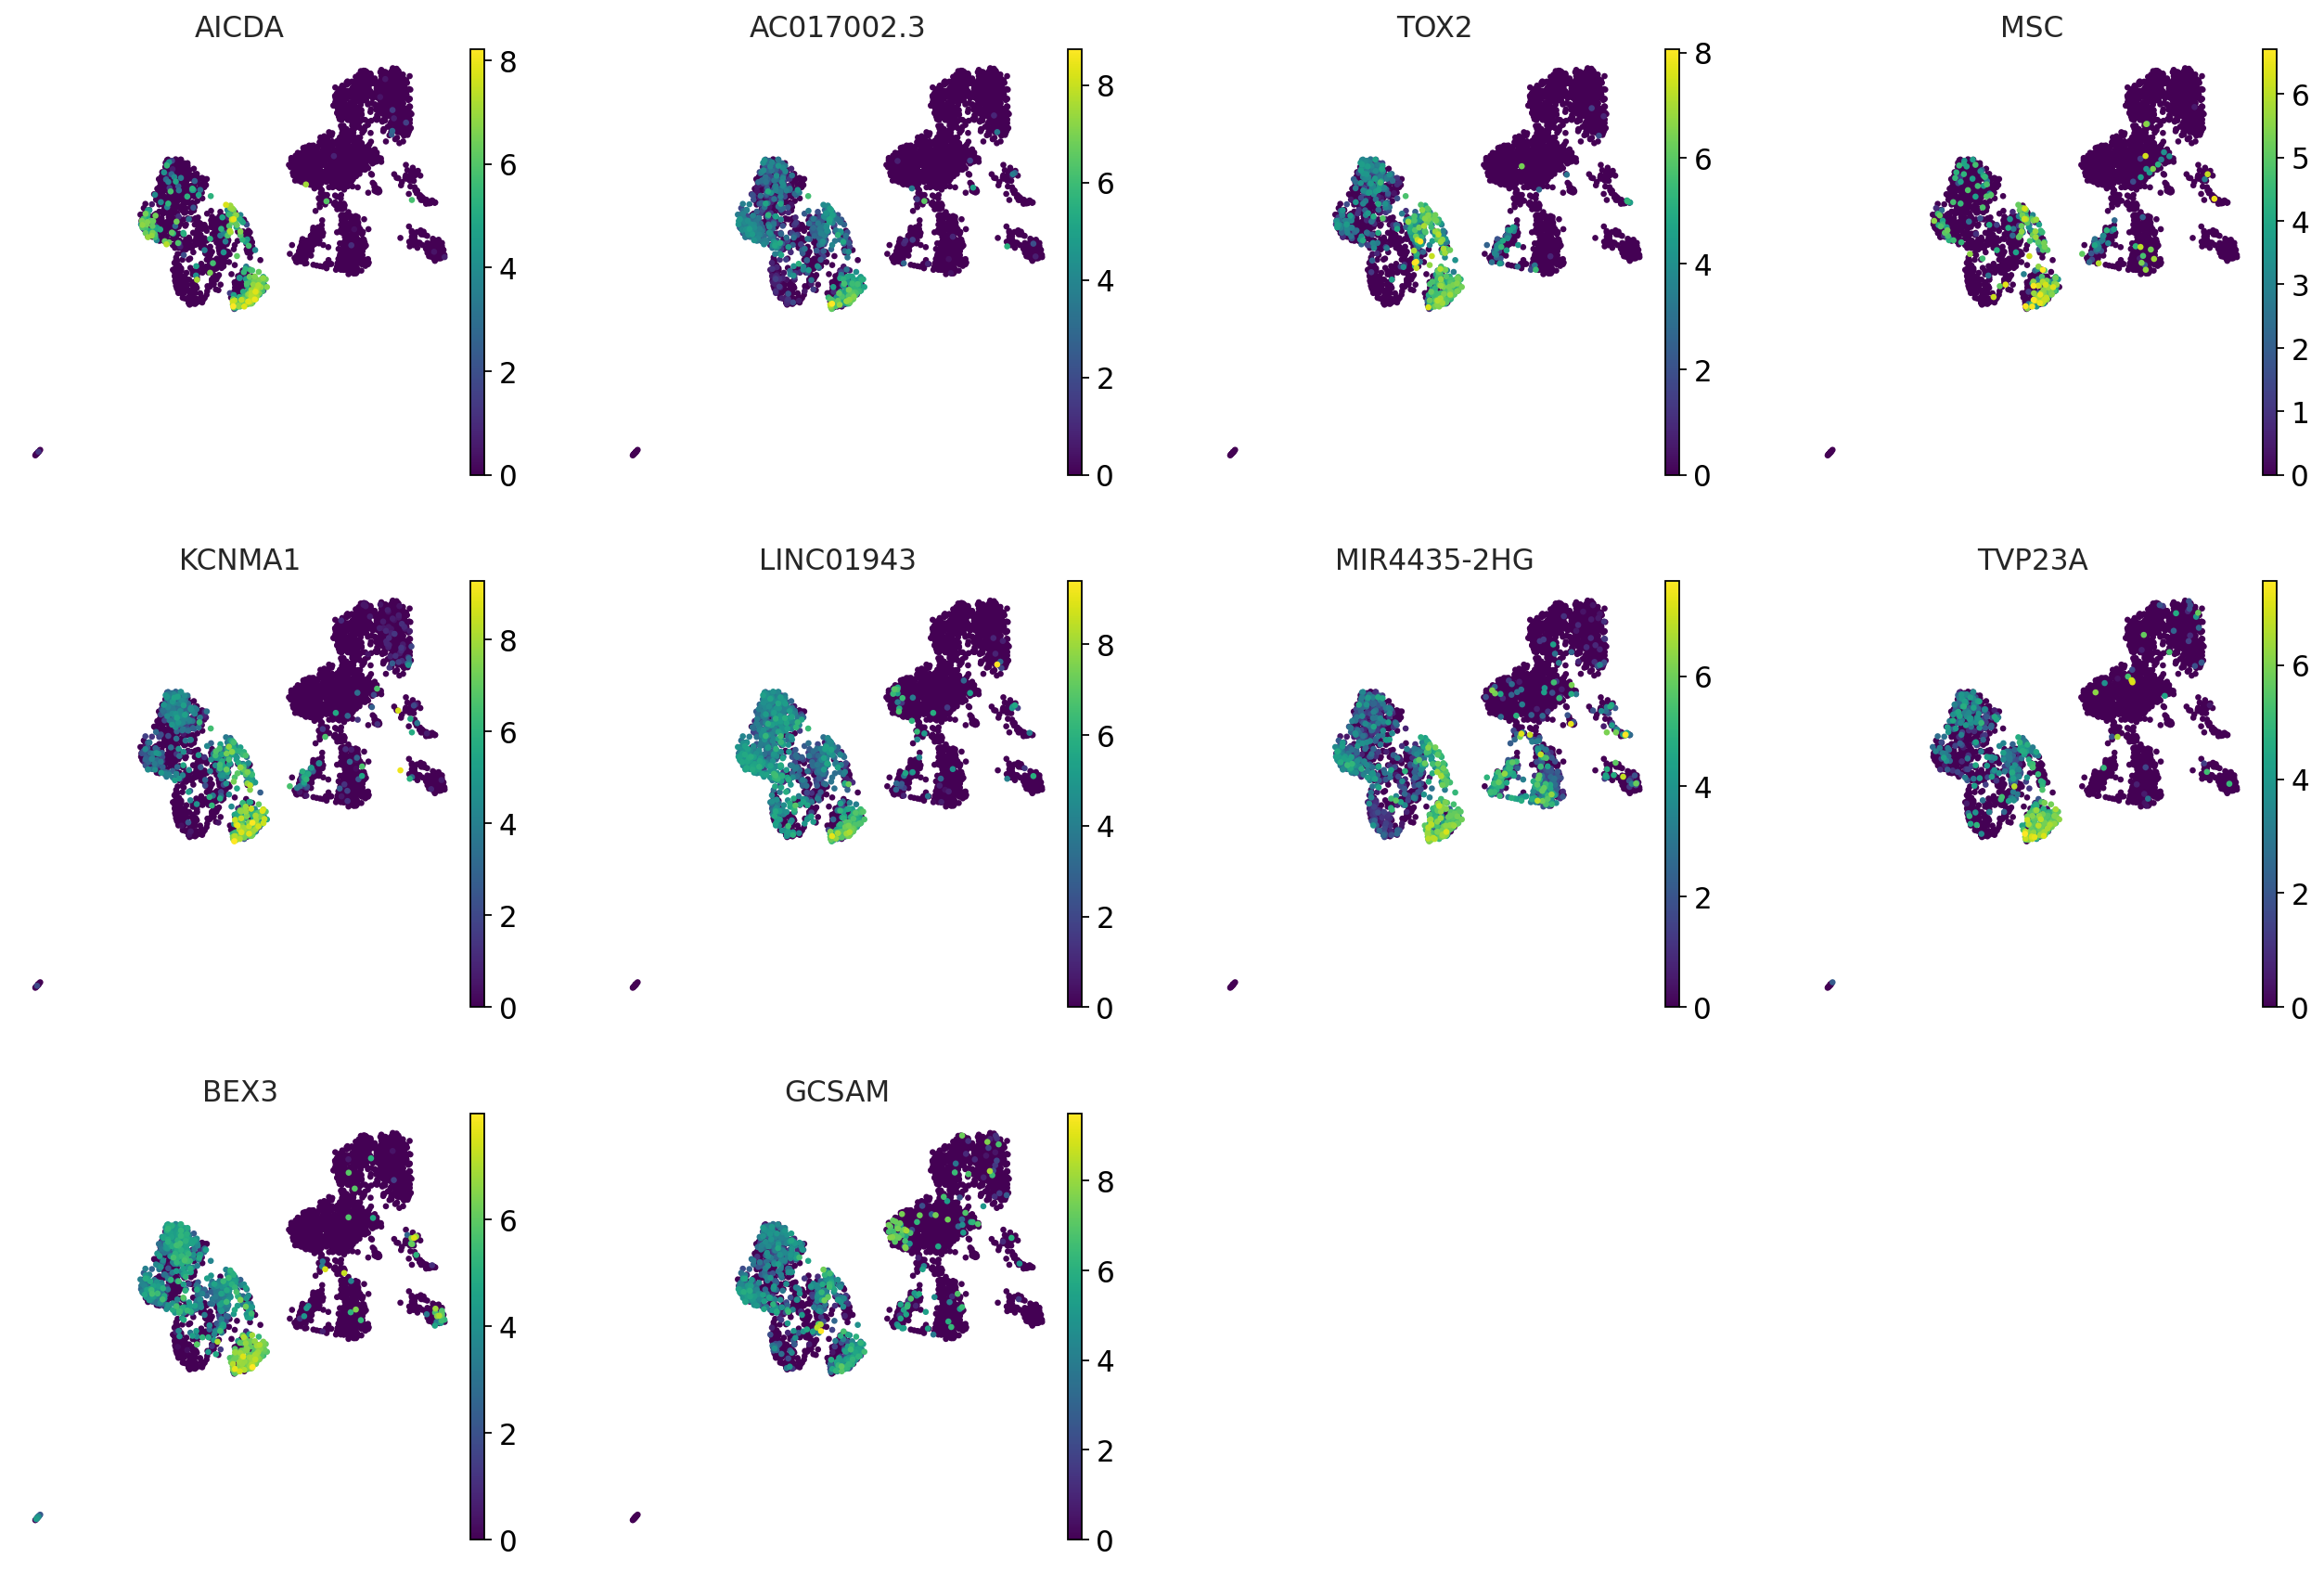

In [52]:
sc.pl.umap(adata, color = genes2plot, save = 'TopCorrAICDAgenes', frameon=False)

In [53]:
TopCorrelatedGOI_GOI = _df[GOI].index[5]

In [1]:
x, y = gene_df[GOI], gene_df[TopCorrelatedGOI_GOI]

fig, ax = plt.subplots(1,1)

plt.scatter(x,y)

plt.xlabel(GOI)
plt.ylabel(TopCorrelatedGOI_GOI)

NameError: name 'gene_df' is not defined

### Transcription Factor Data online

In [55]:
CorrGenes = DictofSerGenes[GOI].index

In [56]:
df_TF = pd.read_csv('../../../SharedData/MetaData/TFs.csv', index_col = 0)

df_TF[df_TF['HGNC symbol'] == 'TOX2']['Final Comments'].to_list()

df_knownTFs = df_TF[df_TF['Is TF?'] == 'Yes']

TFs = set(df_knownTFs['HGNC symbol'].to_list()) & set(CorrGenes)  

TopKnownTfs = DictofSerGenes['AICDA'][DictofSerGenes['AICDA'].index.isin(TFs)]

In [57]:
df_TF.head()

,Ensembl ID,HGNC symbol,DBD,Is TF?,TF assessment,Binding mode,Motif status,Final Notes,Final Comments,Interpro ID(s),EntrezGene ID,EntrezGene Description,PDB ID,TF tested by HT-SELEX?,TF tested by PBM?,Conditional Binding Requirements,Original Comments,Vaquerizas 2009 classification,CisBP considers it a TF?,TFCat classification,Is a GO TF?,Initial assessment,Curator 1,Curator 2,TFclass considers it a TF?,Go Evidence,Pfam Domains (By ENSP ID),Is C2H2 ZF(KRAB)?
0,ENSG00000137203,TFAP2A,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008121;IPR013854,7020,transcription factor AP-2 alpha [Source:HGNC S...,None,DBD,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Sam Lambert,Yimeng Yin,Yes,$#ENSG00000137203#GO:0000981#sequence-specific...,$#ENSP00000368928#ENSG00000137203#ENST00000379...,False
1,ENSG00000008196,TFAP2B,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008122;IPR013854,7021,transcription factor AP-2 beta [Source:HGNC Sy...,None,DBD,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Matt Weirauch,Yimeng Yin,Yes,$#ENSG00000008196#GO:0000981#sequence-specific...,$#ENSP00000377265#ENSG00000008196#ENST00000393...,False
2,ENSG00000087510,TFAP2C,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008123;IPR013854,7022,transcription factor AP-2 gamma [Source:HGNC S...,None,DBD and Full,Yes,None,None,a,Yes,No,Yes,"1a1, Direct HQ evidence",Matt Weirauch,Yimeng Yin,Yes,$#ENSG00000087510#GO:0001077#RNA polymerase II...,$#ENSP00000201031#ENSG00000087510#ENST00000201...,False
3,ENSG00000008197,TFAP2D,AP-2,Yes,Known motif,Monomer or homomultimer,In vivo/Misc source,Only known motifs are from Transfac or HocoMoc...,Binds the same GCCTGAGGC sequence as the other...,IPR013854;,83741,transcription factor AP-2 delta [Source:HGNC S...,None,not tested,not tested,None,None,a,Yes,No,Yes,"2a1, Lower confidence direct evidence",Arttu Jolma,Sam Lambert,Yes,$#ENSG00000008197#GO:0000981#sequence-specific...,$#ENSP00000008391#ENSG00000008197#ENST00000008...,False
4,ENSG00000116819,TFAP2E,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR013854;,339488,transcription factor AP-2 epsilon [Source:HGNC...,None,Full,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Sam Lambert,Laura Campitelli,Yes,$#ENSG00000116819#GO:0000981#sequence-specific...,$#ENSP00000362332#ENSG00000116819#ENST00000373...,False


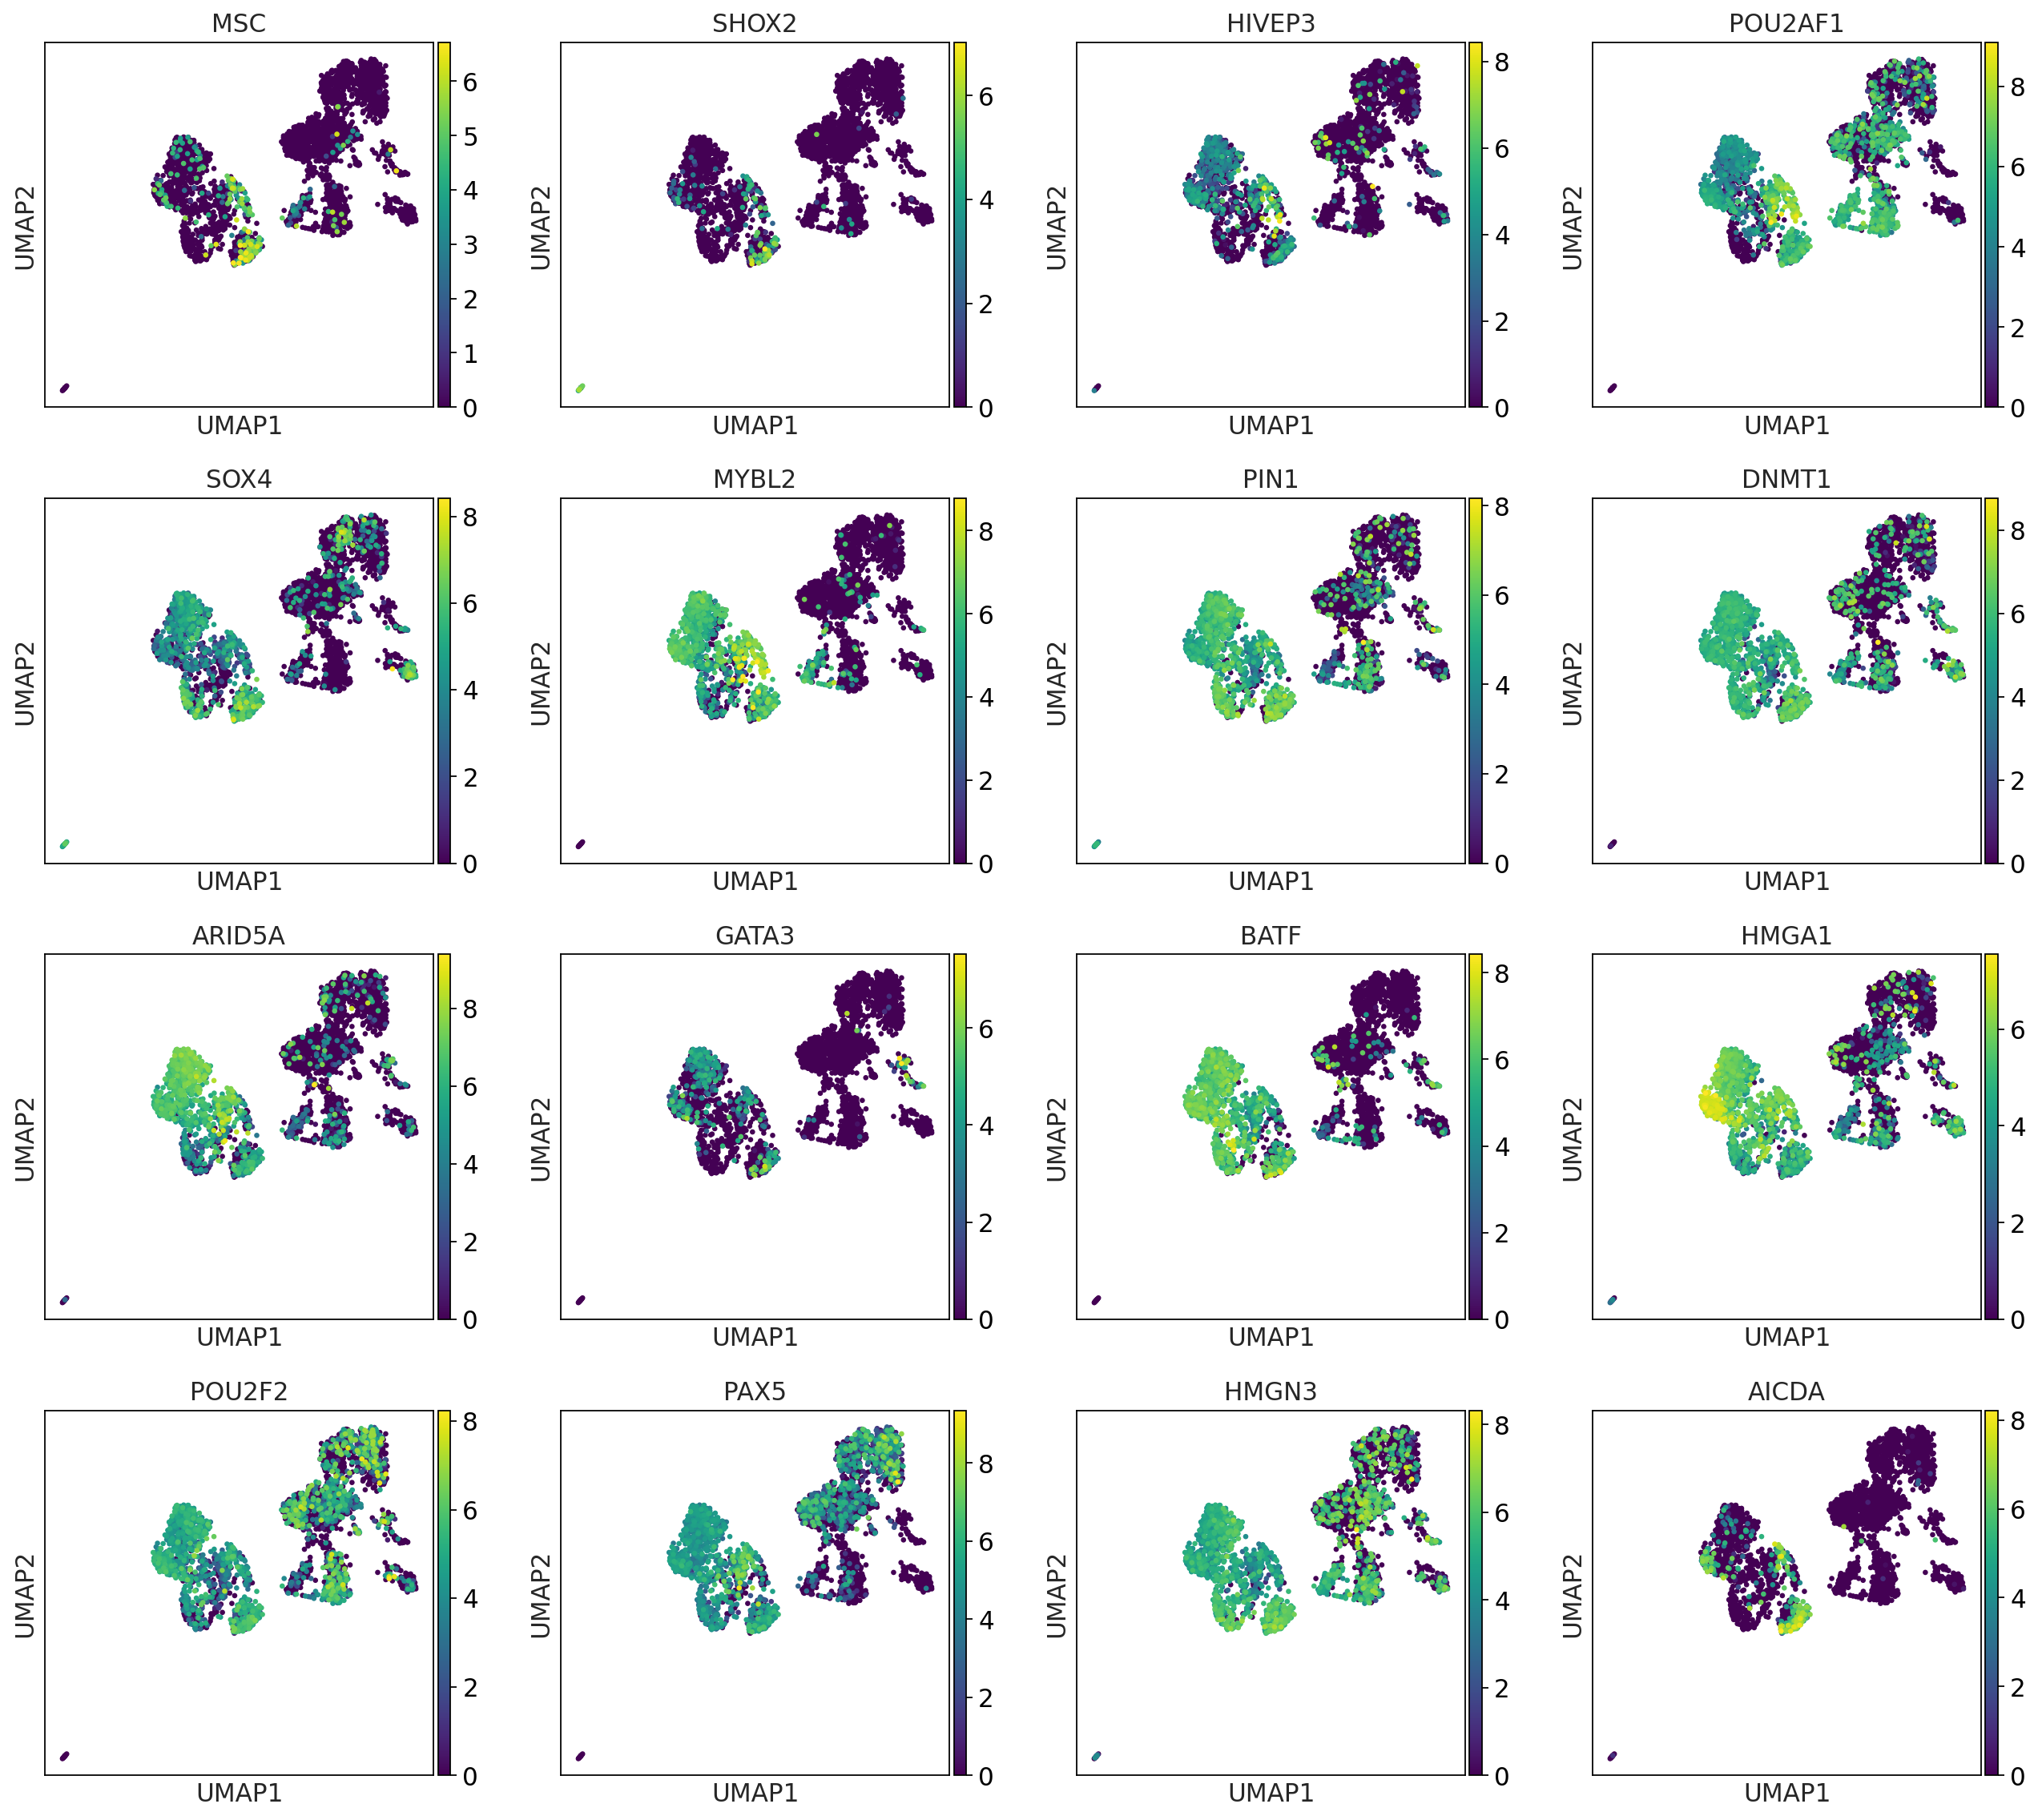

In [58]:
genes2plot = TopKnownTfs.index.to_list()

genes2plot.append('AICDA')

sc.pl.umap(adata, color = genes2plot, save='TFassociatedAICDA')

Text(0, 0.5, 'MYBL2')

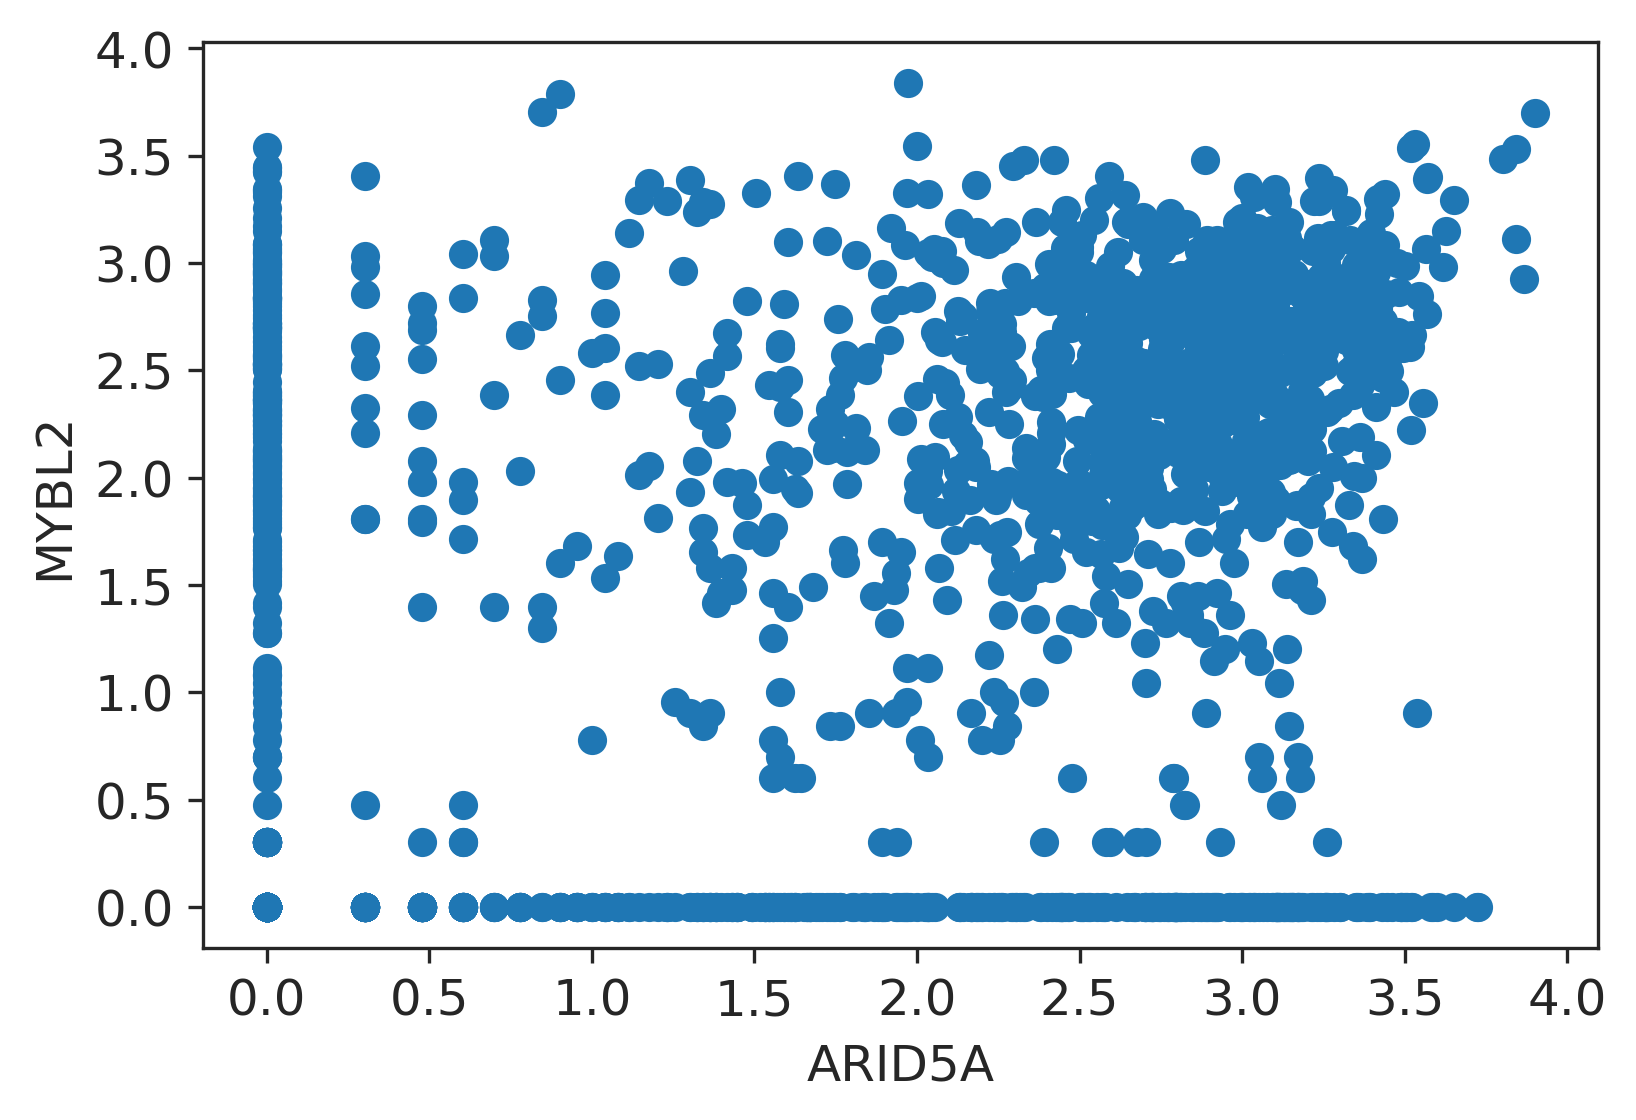

In [195]:
fig, ax = plt.subplots(1,1)

plt.scatter(x,y)

plt.xlabel(GOI)
plt.ylabel(TopCorrelatedGOI_GOI)